In [11]:
include("copper.jl");

# Anderson acceleration

It makes sense to apply Anderson acceleration to the preconditioned problem because it's an integral equation. 
Using Anderson acceleration without preconditioning is not the right thing for __this particular problem.__
We will show results without preconditioning at the end of this section to illustrate this point.

Anderson(1) seems to be better for this problem, but the
osciallations in the gradient history do not give much guidance
for a termination criteria. 

### Algorithm 1

Algorithm is simply damped Picard iteration for a fixed point problem. To see this we use the definition
$$
u_{k+1} =  u_k - \tau F(u_k)
$$

So we can use $G(u) = u_k - \tau F(u_k)$ as the fixed point map. Lei's work describes the 
behavior of the fixed point iteration.

If we precondition we replace $F$ by $L^{-1} F$ and so $G$ is now
$$
\begin{array}{ll}
G(u) & =  u_k - \tau L^{-1} F(u_k) \\
& = u_k - \tau L^{-1} (L u_k + N(u_k)) \\
& =  u_k - \tau (u_k + L^{-1} N(u_k))\\
& = (1 - \tau) u_k + \tau {\hat G}(u_k),
\end{array}
$$
where ${\hat G} = - L^{-1} F$. So the iteration $u_k = G(u_k)$ is the same as damped Picard iteration for 
${\hat G}$. ${\hat G}$ is a discrete nonlinear integral operator. That is the kind of prolbem that
AA was designed to solve efficiently.



The next figure varies $\tau$ for fixed $\alpha$.

Ex 1; Precond = true; Fixed alpha = 0.5; vary tau
Failure to converge after 100 iterations for m=1 in aasol.jl
Failure to converge after 100 iterations for m=1 in aasol.jl


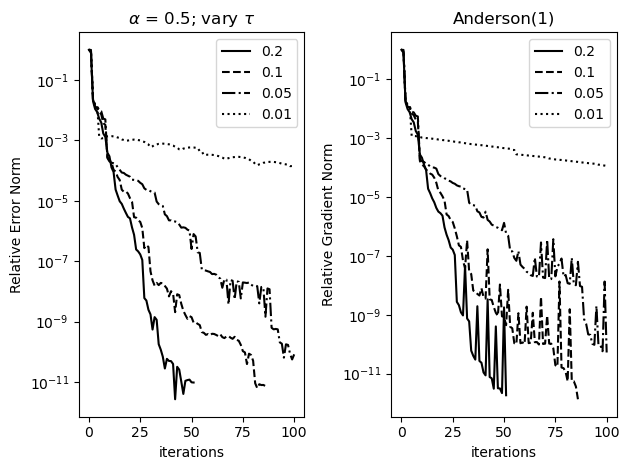

In [12]:
aa_test_copper(15; maxit=100);

We now examine the dependence on $\alpha$.

Ex 1; Precond = true; Fixed tau = 0.1; vary alpha
Failure to converge after 100 iterations for m=1 in aasol.jl
Failure to converge after 100 iterations for m=1 in aasol.jl
Failure to converge after 100 iterations for m=1 in aasol.jl


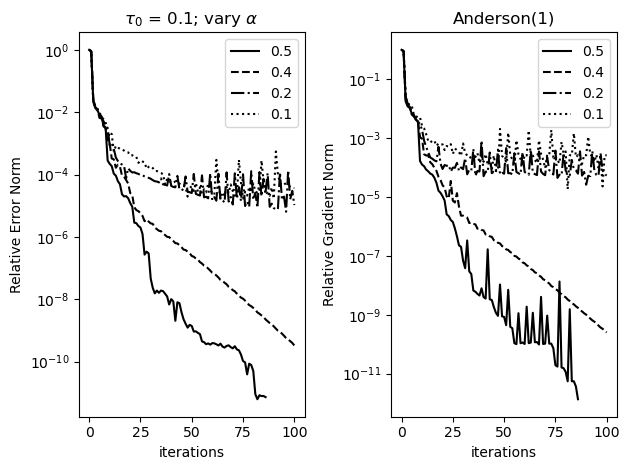

In [13]:
aa_alpha_copper(15; maxit=100);

If we fail to precondition the results are worse.

Ex 1; Precond = false; Fixed alpha = 0.5; vary tau
Failure to converge after 1000 iterations for m=1 in aasol.jl
Failure to converge after 1000 iterations for m=1 in aasol.jl
Failure to converge after 1000 iterations for m=1 in aasol.jl
Failure to converge after 1000 iterations for m=1 in aasol.jl


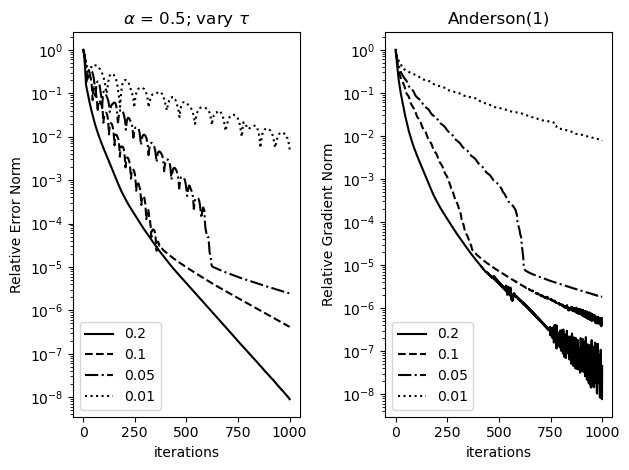

In [14]:
aa_test_copper(15; maxit=1000, precond=false);

Ex 1; Precond = false; Fixed tau = 0.1; vary alpha
Failure to converge after 1000 iterations for m=1 in aasol.jl
Failure to converge after 1000 iterations for m=1 in aasol.jl
Failure to converge after 1000 iterations for m=1 in aasol.jl
Failure to converge after 1000 iterations for m=1 in aasol.jl


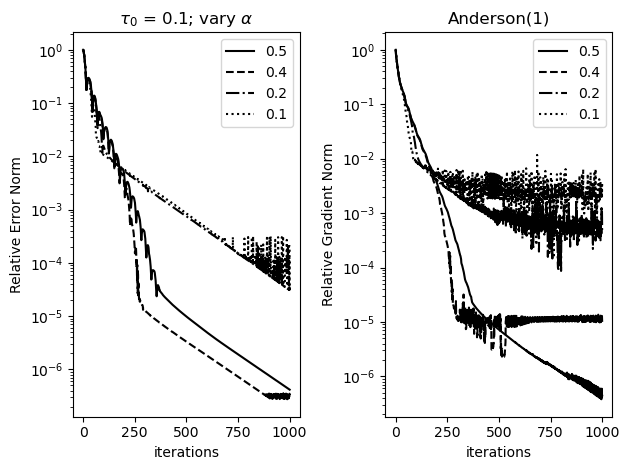

In [15]:
aa_alpha_copper(15; maxit=1000, precond=false);

### Two Stage Algorithm

For the two stage algoritm the fixed point map $G_2$ can be derived directly. The iteration is
$$
\begin{array}{ll}
y_k & = u_k - \tau F(u_k)\\
u_{k+1} &= u_k - \tau F(y_k)
\end{array}

So
$$
G_2(u_k) = u_k - \tau F(u_k - \tau F(u_k))
$$

The preconditioned form of $G_2$ applies $L^{-1}$ to both instances of $F$.
$$
G_2(u_k) = u_k - \tau L^{-1} F(u_k - \tau L^{-1} F(u_k))
$$

We will do the same experiments as for the first algorithm. First we fix $\alpha$ and vary $\tau$.

Ex 1; Precond = true; Fixed alpha = 0.5; vary tau


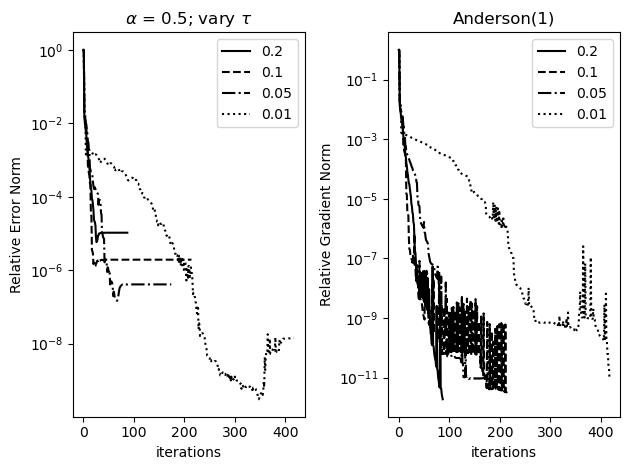

In [16]:
aa_test_copper(15; GF=GF2!)

Now fix $\tau$ and vary $\alpha$.

Ex 1; Precond = true; Fixed tau = 0.1; vary alpha
Failure to converge after 200 iterations for m=1 in aasol.jl
Failure to converge after 200 iterations for m=1 in aasol.jl
Failure to converge after 200 iterations for m=1 in aasol.jl
Failure to converge after 200 iterations for m=1 in aasol.jl


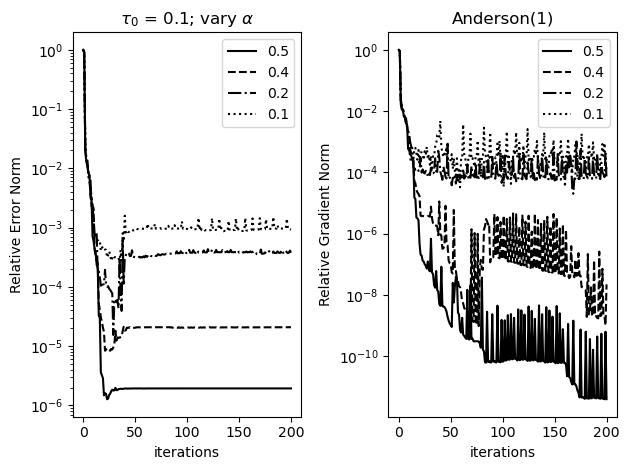

In [17]:
aa_alpha_copper(15; GF=GF2!,maxit=200)

Now for the unpreconditioned cases.

Ex 1; Precond = false; Fixed alpha = 0.5; vary tau
Diverging for m=1 in aasol.jl.
Failure to converge after 2000 iterations for m=1 in aasol.jl
Failure to converge after 2000 iterations for m=1 in aasol.jl


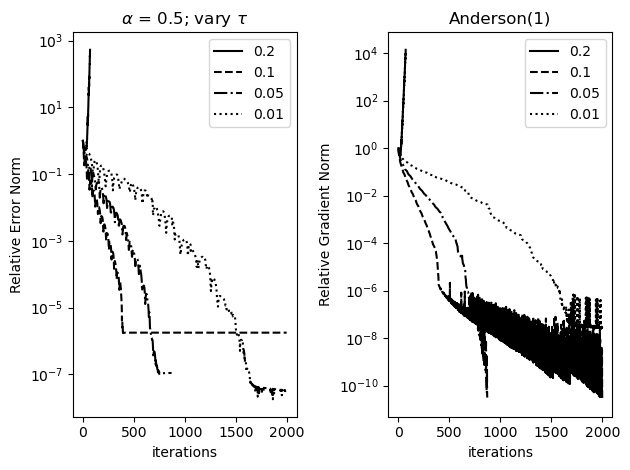

In [18]:
aa_test_copper(15; GF=GF2!, precond=false, maxit=2000)

Ex 1; Precond = false; Fixed tau = 0.1; vary alpha
Failure to converge after 500 iterations for m=1 in aasol.jl
Failure to converge after 500 iterations for m=1 in aasol.jl
Failure to converge after 500 iterations for m=1 in aasol.jl
Failure to converge after 500 iterations for m=1 in aasol.jl


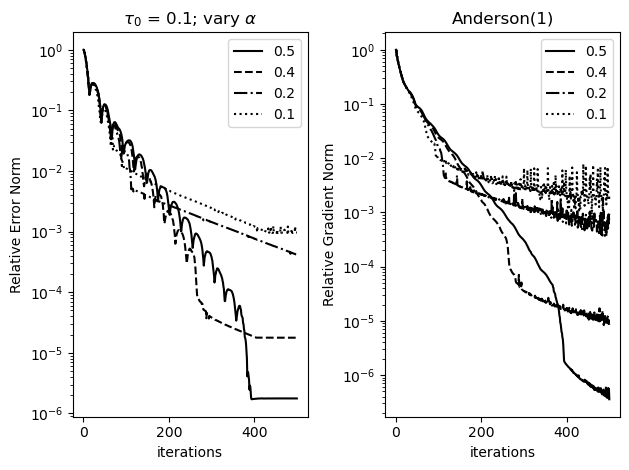

In [19]:
aa_alpha_copper(15; GF=GF2!,maxit=500, precond=false)